# Heatmap visualization — see the raw token×token attribution matrix

`POST /v1/attributions` gives you resolved spans — the right call for products.
Underneath it is `POST /v1/attributions/heatmap`: the raw **answer-token ×
document-token** attribution matrix, measured from model attention. Use it when
you want to *see* how an answer rests on its source, debug a surprising
attribution, or build your own span rollup.

This notebook calls the heatmap endpoint, densifies the sparse response, and
renders it with matplotlib.

## Setup

You need a TokenPath API key — free at [platform.tokenpath.ai](https://platform.tokenpath.ai)
(10M attributed tokens on signup, no card required). Export it as `TOKENPATH_API_KEY`
before running this notebook.

In [1]:
%pip install -q requests numpy matplotlib

In [2]:
import os

import numpy as np
import requests

API_URL = "https://api.tokenpath.ai"
API_KEY = os.environ.get("TOKENPATH_API_KEY")
assert API_KEY, (
    "Set TOKENPATH_API_KEY first — grab a free key (10M tokens, no card) "
    "at https://platform.tokenpath.ai"
)


def heatmap(document, question, answer, **options):
    """Return the raw sparse token-level attribution heatmap."""
    response = requests.post(
        f"{API_URL}/v1/attributions/heatmap",
        headers={"Authorization": f"Bearer {API_KEY}"},
        json={"document": document, "question": question, "answer": answer, **options},
        timeout=120,
    )
    response.raise_for_status()
    return response.json()

In [3]:
DOCUMENT = """NORTHWIND TRADERS — Q3 2025 SHAREHOLDER NOTE

Revenue grew 18% year over year to $412 million, driven primarily by the
Enterprise segment, which expanded 31%. Gross margin improved to 64.2%,
up from 61.8% a year ago. The company closed the quarter with 2,847
employees, up from 2,610 at the end of Q2.

Operating expenses rose 9% to $198 million, reflecting continued
investment in the Fabrikam integration, which remains on track to
complete in Q1 2026. The board approved a $50 million share buyback
program. No dividend was declared this quarter.

CEO Elena Vasquez said the company expects "mid-teens revenue growth"
for the full fiscal year, citing a record $1.2 billion contracted
backlog. Guidance assumes no material FX headwinds."""

QUESTION = "Summarize Northwind's Q3 results."

In [4]:
ANSWER = (
    "Northwind's revenue grew 18% year over year to $412 million, led by 31% "
    "growth in the Enterprise segment. Gross margin improved to 64.2%. The "
    "board approved a $50 million share buyback, and the company guided to "
    "mid-teens revenue growth for the full year."
)

sparse = heatmap(DOCUMENT, QUESTION, ANSWER)
print("shape [answer_tokens, document_tokens]:", sparse["shape"])
print("non-zero entries:", len(sparse["data"]))

shape [answer_tokens, document_tokens]: [62, 188]
non-zero entries: 769


## The response is a sparse COO matrix over *tokens*

Three parallel arrays — `row` (answer-token index), `col` (document-token
index), `data` (attribution weight) — plus `answer_offsets` /
`document_offsets`, which map each token index back to `[charStart, charEnd)`
in the text you sent. Two things to keep straight:

- **Orientation is `[answer, document]`** — rows are answer tokens.
- **Weights are unnormalized.** They're summed cleaned attention, comparable
  *relatively* within a response — they are not probabilities.

In [5]:
matrix = np.zeros(sparse["shape"])
matrix[sparse["row"], sparse["col"]] = sparse["data"]

answer_tokens = [ANSWER[s:e] for s, e in sparse["answer_offsets"]]
document_tokens = [DOCUMENT[s:e] for s, e in sparse["document_offsets"]]

print(f"{matrix.shape=}, density={np.count_nonzero(matrix) / matrix.size:.1%}")
print("first answer tokens:", answer_tokens[:6])

matrix.shape=(62, 188), density=6.6%
first answer tokens: ['North', 'wind', "'s", ' revenue', ' grew', ' ']


## The full matrix

One hue, light → dark with weight. The diagonal-ish bands are the answer
walking through the document in order; bright cells are tokens copied straight
from the source.

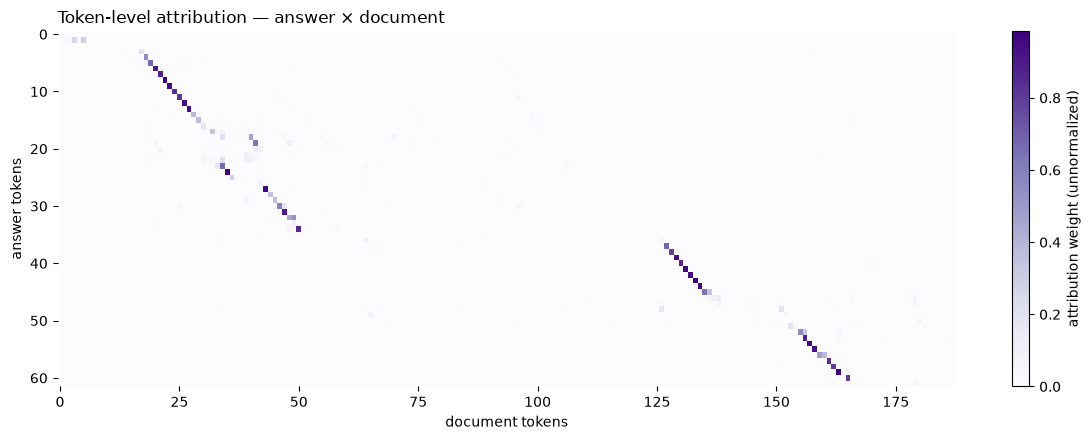

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.imshow(matrix, aspect="auto", cmap="Purples", interpolation="nearest")
ax.set_xlabel("document tokens")
ax.set_ylabel("answer tokens")
ax.set_title("Token-level attribution — answer × document", loc="left")
for spine in ax.spines.values():
    spine.set_visible(False)
fig.colorbar(im, ax=ax, label="attribution weight (unnormalized)")
plt.tight_layout()
plt.show()

## Zoom into one answer token

Pick the token for "18%" in the answer and look at its row: which document
tokens produced it?

In [7]:
token_index = next(i for i, t in enumerate(answer_tokens) if "18" in t)
row = matrix[token_index]

print(f"answer token {token_index}: {answer_tokens[token_index]!r}\n")
for d in row.argsort()[::-1][:6]:
    if row[d] > 0:
        print(f"  {row[d]:.3f}  document token {d}: {document_tokens[d]!r}")

answer token 6: '18'

  0.906  document token 20: '8%'
  0.037  document token 21: ' '
  0.015  document token 94: '%'
  0.012  document token 48: '4.'
  0.003  document token 19: '1'
  0.003  document token 41: '1%'


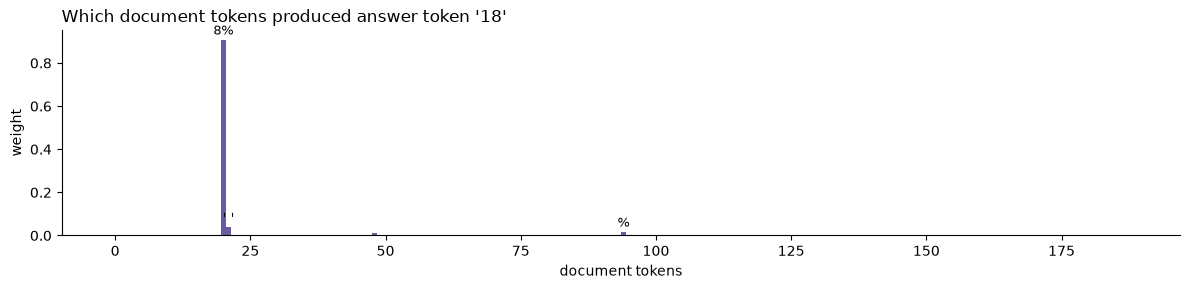

In [8]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(range(len(row)), row, width=1.0, color="#6b5a9e")
ax.set_xlabel("document tokens")
ax.set_ylabel("weight")
ax.set_title(
    f"Which document tokens produced answer token {answer_tokens[token_index]!r}",
    loc="left",
)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

top = [d for d in row.argsort()[::-1][:3] if row[d] > 0]
for d in top:
    ax.annotate(
        document_tokens[d].strip() or repr(document_tokens[d]),
        (d, row[d]),
        textcoords="offset points",
        xytext=(0, 4),
        ha="center",
        fontsize=9,
    )
plt.tight_layout()
plt.show()

## Claim-level view: sum rows over a claim's tokens

Summing the rows of all tokens in a claim gives that claim's per-document-token
support — the basis for rolling the heatmap up into "claim → best source
span".

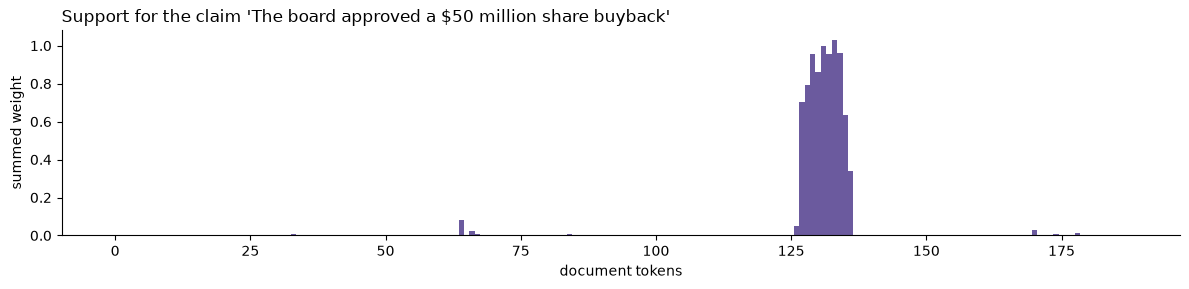

strongest source region: 'board approved a $50 million share buyback\nprogram. No'


In [9]:
claim = "The board approved a $50 million share buyback"
claim_start = ANSWER.index(claim)
claim_end = claim_start + len(claim)

claim_rows = [
    k
    for k, (s, e) in enumerate(sparse["answer_offsets"])
    if e > claim_start and s < claim_end
]
support = matrix[claim_rows].sum(axis=0)

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(range(len(support)), support, width=1.0, color="#6b5a9e")
ax.set_xlabel("document tokens")
ax.set_ylabel("summed weight")
ax.set_title(f"Support for the claim {claim!r}", loc="left")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

best = support.argmax()
start_char = sparse["document_offsets"][max(0, best - 6)][0]
end_char = sparse["document_offsets"][min(len(support) - 1, best + 6)][1]
print(f"strongest source region: {DOCUMENT[start_char:end_char].strip()!r}")

## Rolling up to spans — or letting the API do it

The full rollup (segment the answer into claims → map claim characters to
answer tokens → score document tokens → take the best contiguous run with a
small length penalty) is exactly what `POST /v1/attributions` does for you,
returning character spans plus a normalized confidence. Reach for the raw
heatmap only when you need the matrix itself — custom rollups, research, or
visual debugging like this notebook.

---

## Where to go next

- **API reference & guides** — [docs.tokenpath.ai](https://docs.tokenpath.ai)
- **Bugs / broken examples** — [open an issue](https://github.com/tokenpath/tokenpath-cookbook/issues)
- **"How do I…?"** — [start a discussion](https://github.com/tokenpath/tokenpath-cookbook/discussions)
- **Email** — support@tokenpath.ai